# Titanic Data Cleaning & Analysis

## SECTION 1: Problem Statement
The sinking of the Titanic is one of the most infamous shipwrecks in history. While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this project, we will:
1. Load the real Titanic dataset.
2. Clean missing data using NumPy and Pandas.
3. Explore survival rates using Matplotlib.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# SECTION 2: Load Dataset
# Ensure you have run download_data.py first!
df = pd.read_csv('titanic.csv')
print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## SECTION 3: Data Exploration
Let's see what we're working with.


In [2]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print("\nMissing Values per Column:")
print(df.isnull().sum())


Rows: 891, Columns: 12

Missing Values per Column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


## SECTION 4: Data Cleaning
We need to handle the missing `Age` values and remove columns that don't help with survival prediction.


In [3]:
# 1. Fill missing Age with the median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

# 2. Drop columns that are unlikely to affect survival
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

print("Data Cleaned!")
df.head()


Data Cleaned!


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## SECTION 5: Feature Engineering
Let's simplify some data. For example, convert 'Sex' to numbers.


In [4]:
df['Sex'] = df['Sex'].map({'female': 1, 'male': 0})
df.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,S
1,1,1,1,38.0,1,0,71.2833,C
2,1,3,1,26.0,0,0,7.9250,S
3,1,1,1,35.0,1,0,53.1000,S
4,0,3,0,35.0,0,0,8.0500,S


## SECTION 6: Visualization
Which class had the best survival rate?


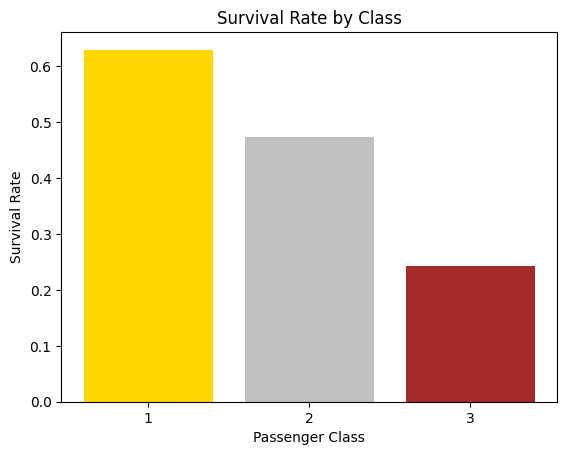

In [ ]:
survival_by_class = df.groupby('Pclass')['Survived'].mean()

plt.bar(survival_by_class.index.to_numpy(), survival_by_class.to_numpy(), color=['gold', 'silver', 'brown'])
plt.xticks([1, 2, 3])
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.title('Survival Rate by Class')
plt.show()

## SECTION 7: Analysis / Insights
From the chart above, we can see that **1st class** passengers had a significantly higher survival rate than 3rd class.

## SECTION 8: Final Thoughts
Data cleaning is 80% of a data scientist's job. By filling missing values and removing noise, we've prepared this dataset for more advanced AI models in the next projects!
